In [1]:
! pip install --upgrade xarray zarr gcsfs cftime nc-time-axis

  Using cached pyasn1_modules-0.4.2-py3-none-any.whl.metadata (3.5 kB)
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 1.4/1.4 MB 72.0 MB/s  0:00:00
   ---------------------------------------- 0.0/3.8 MB ? eta -:--:--
   ---------------------------------------- 3.8/3.8 MB 75.6 MB/s  0:00:00
   ---------------------------------------- 0.0/801.4 kB ? eta -:--:--
   ---------------------------------------- 801.4/801.4 kB 33.7 MB/s  0:00:00
Using cached pyasn1_modules-0.4.2-py3-none-any.whl (181 kB)
   ---------------------------------------- 0.0/4.9 MB ? eta -:--:--
   ---------------------------------------- 4.9/4.9 MB 98.3 MB/s  0:00:00

   ----------------------------------------  0/36 [pyyaml]
   - --------------------------------------  1/36 [pyasn1]
   - --------------------------------------  1/36 [pyasn1]
   -- -------------------------------------  2/36 [protobuf]
   -- -------------------------------------  2/36 [p

In [12]:
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
import gcsfs

df = pd.read_csv('https://storage.googleapis.com/cmip6/cmip6-zarr-consolidated-stores.csv')

# 3. Filter for ISOLATED Greenhouse Gas Effects
# We use experiment_id='hist-GHG' to remove non-GHG factors
df_ghg_only = df.query("experiment_id == 'hist-GHG' & table_id == 'Amon' & variable_id == 'tas' & institution_id == 'NCAR'")

# 4. Load Data
gcs = gcsfs.GCSFileSystem(token='anon')
zstore = df_ghg_only.iloc[0].zstore # Pulling the first NCAR GHG-only store[cite: 4]
ds = xr.open_zarr(gcs.get_mapper(zstore), consolidated=True)

# Example: Plotting the first time step of the temperature data
# ds.tas.isel(time=0).plot()

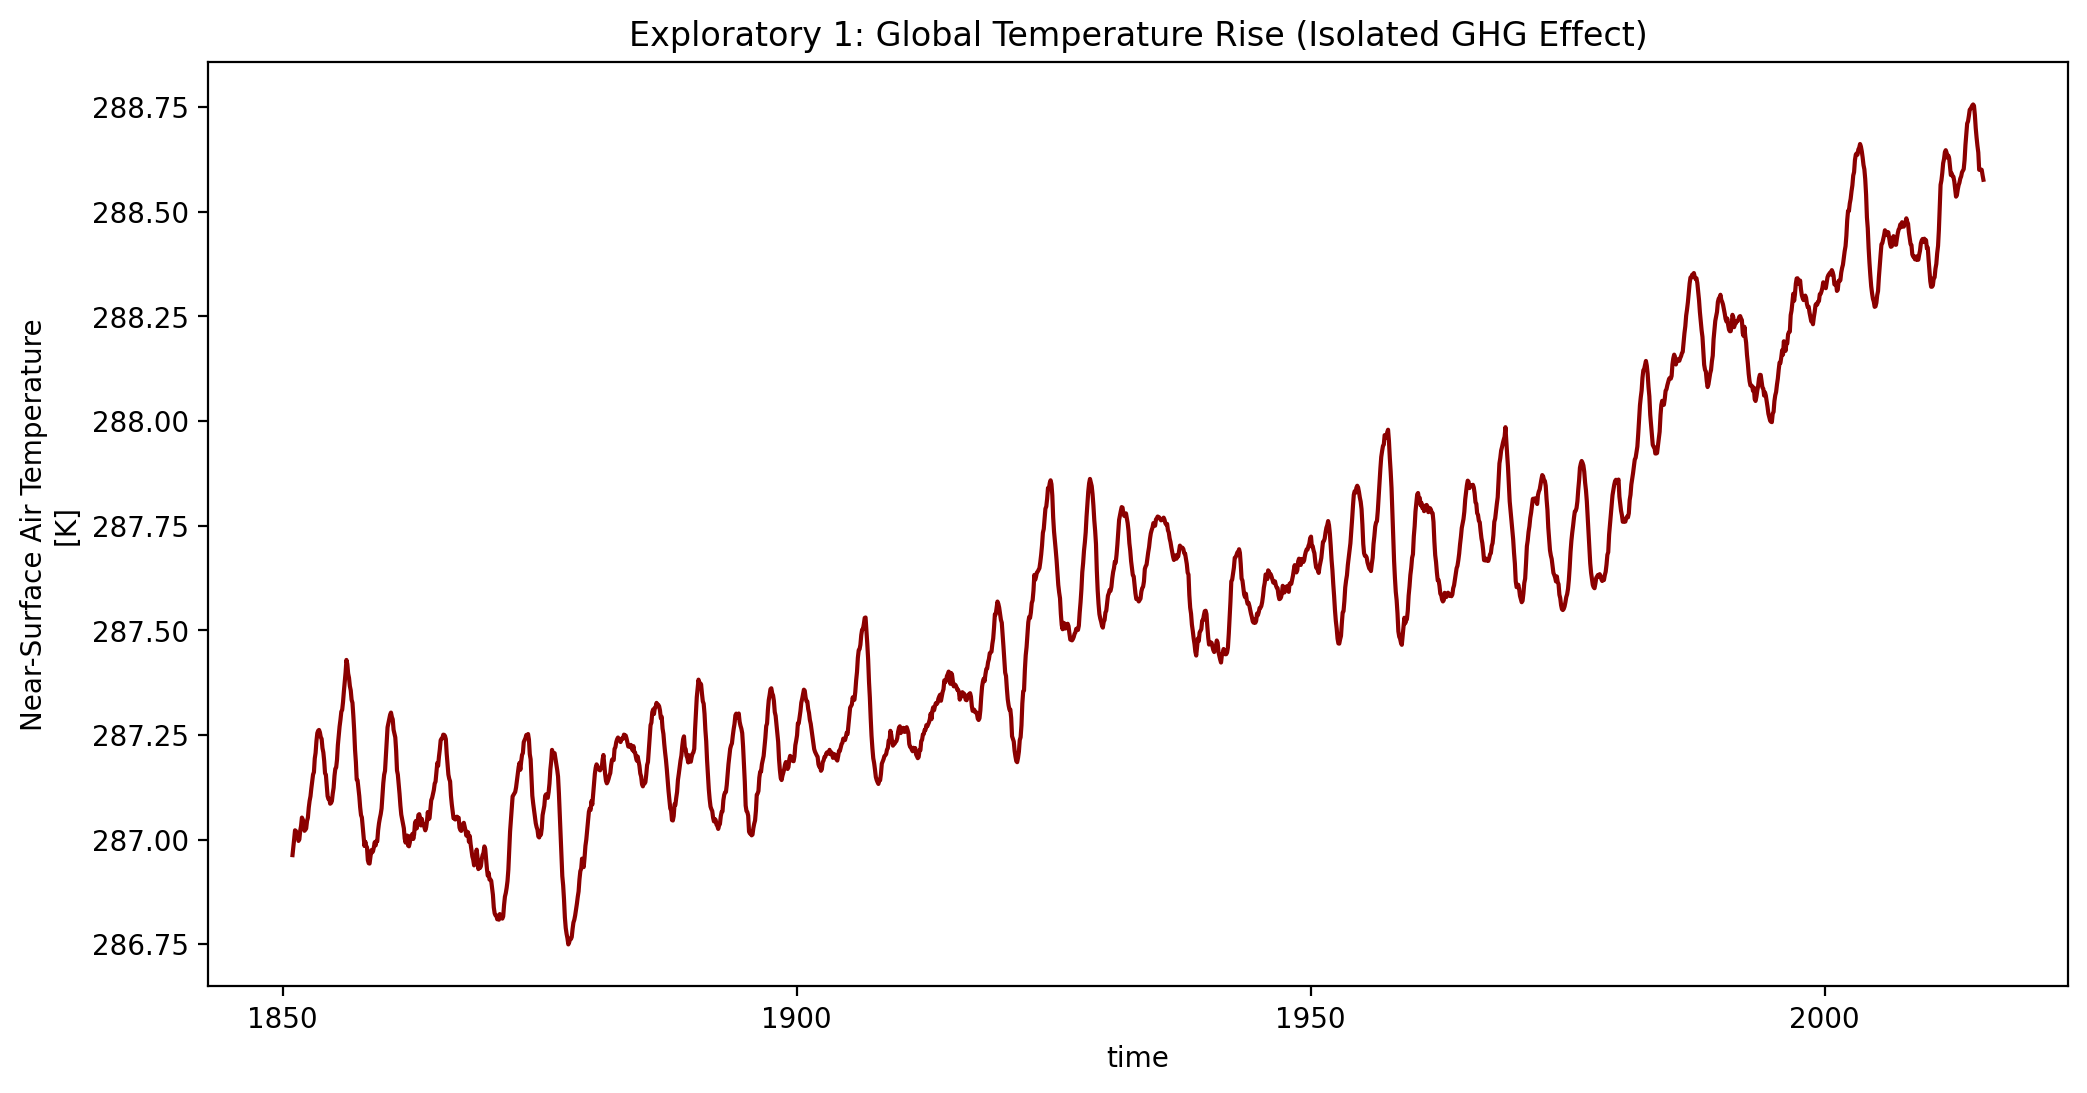

In [13]:
weights = np.cos(np.deg2rad(ds.lat))
ghg_ts = ds.tas.weighted(weights).mean(dim=['lat', 'lon'])
ghg_ts.rolling(time=12).mean().plot(color='darkred')
plt.title("Exploratory 1: Global Temperature Rise (Isolated GHG Effect)")
plt.show()



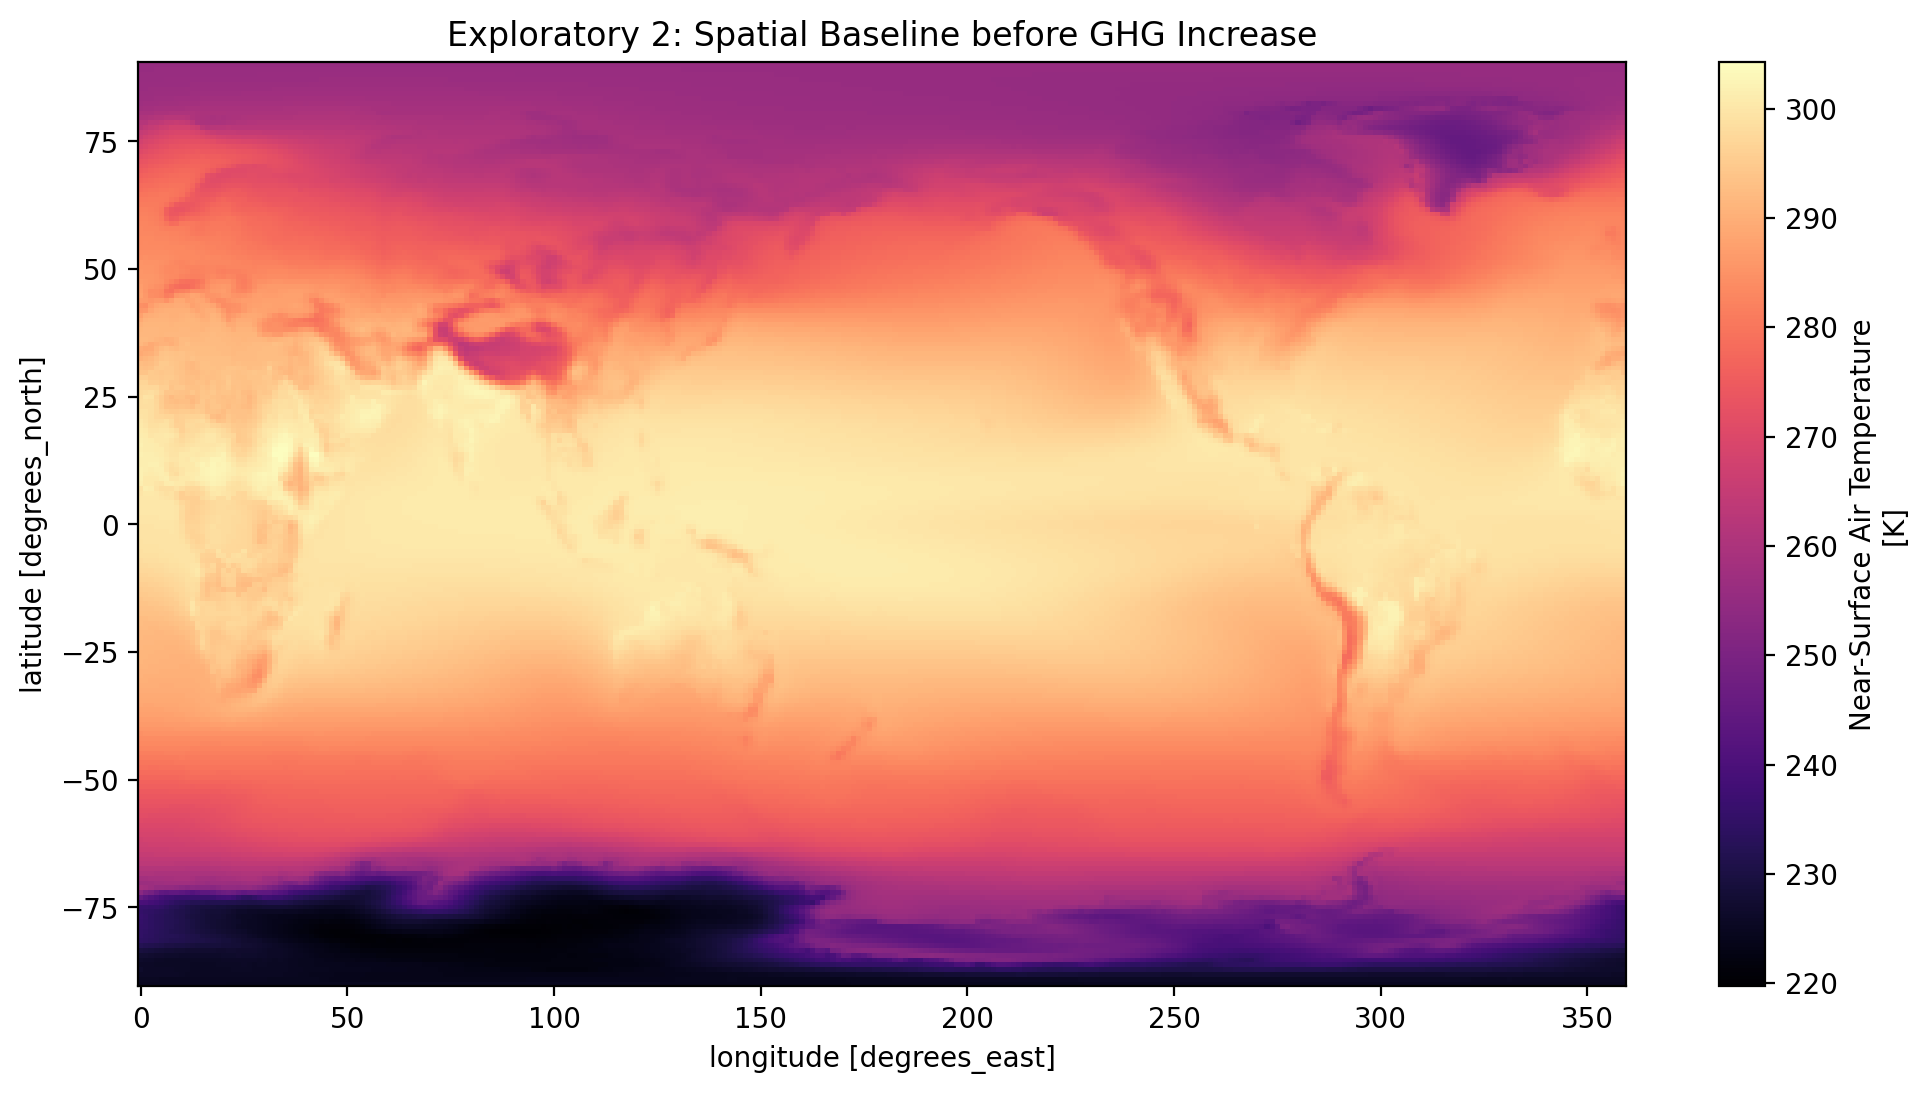

In [14]:
baseline = ds.tas.sel(time=slice("1850", "1880")).mean(dim="time")
baseline.plot(cmap='magma')
plt.title("Exploratory 2: Spatial Baseline before GHG Increase")
plt.show()

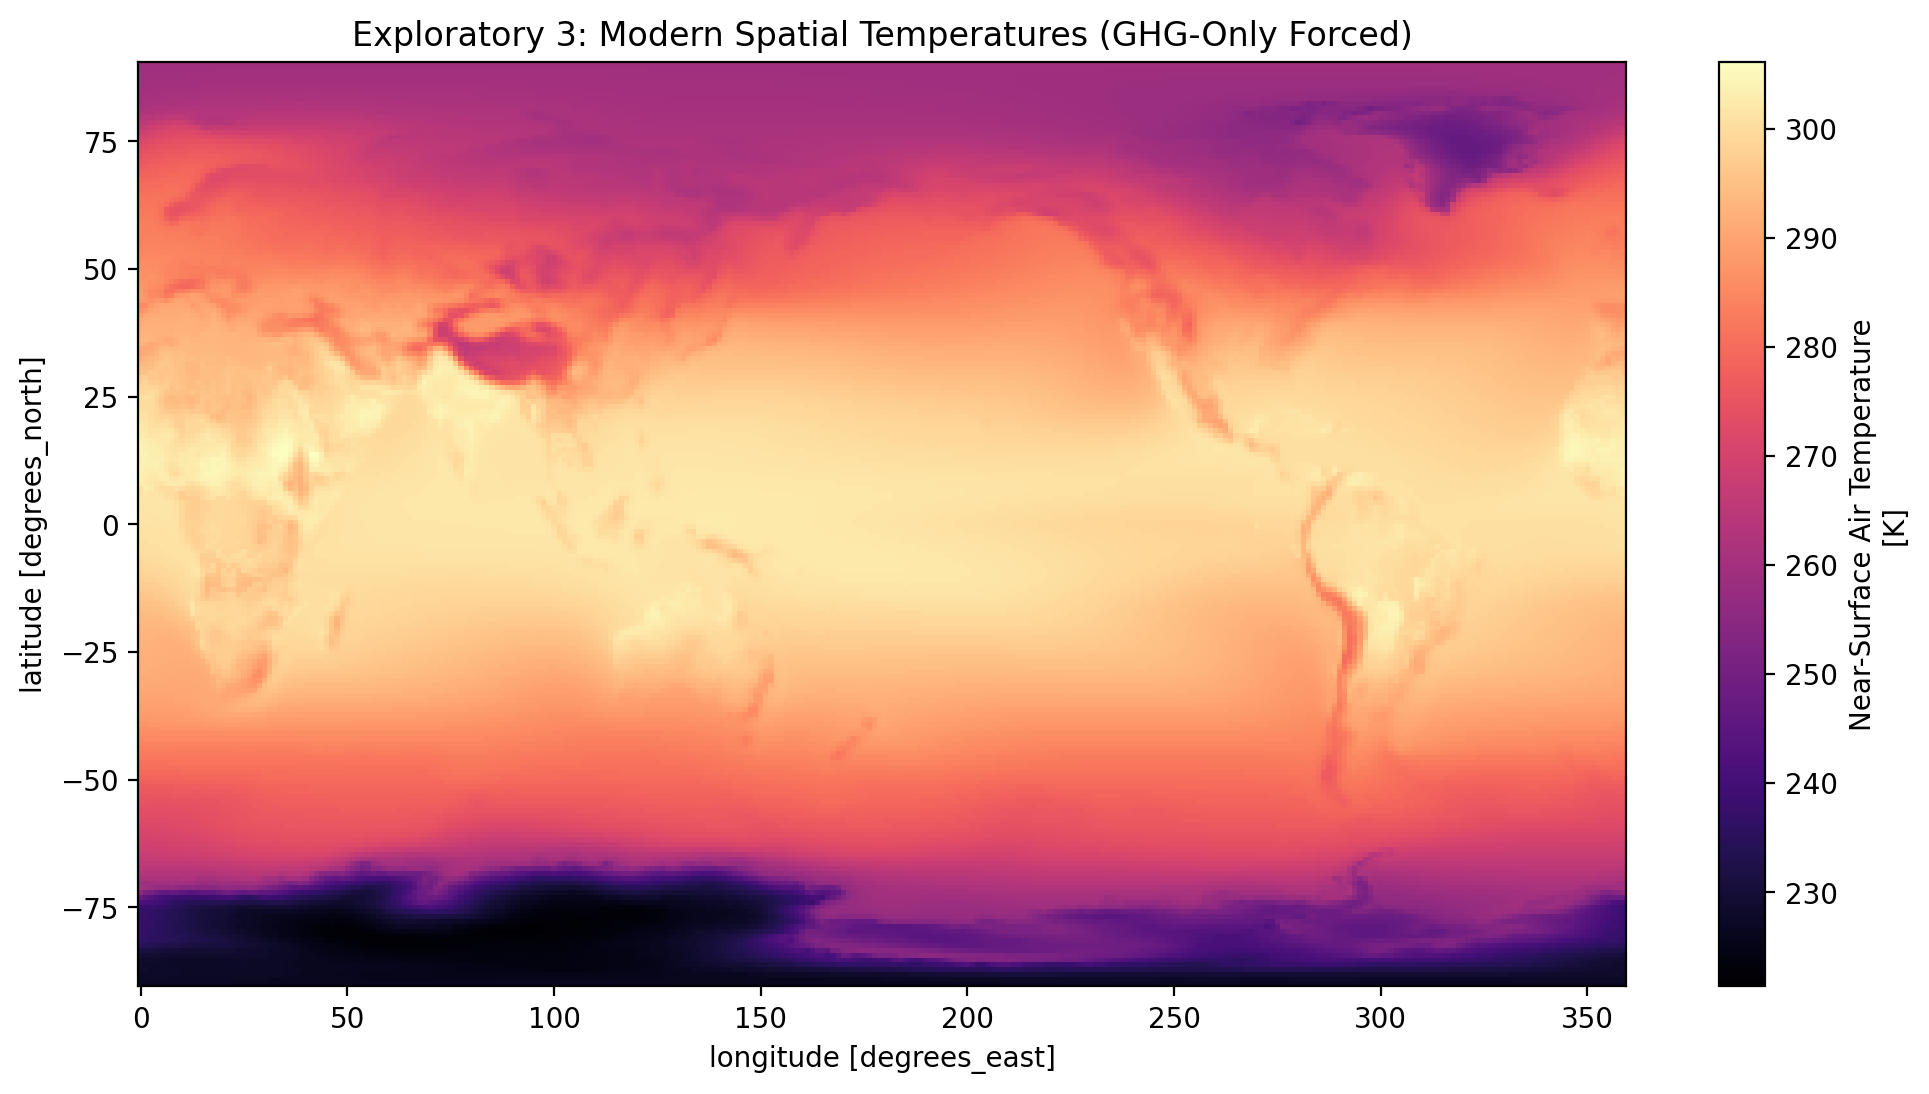

In [15]:
modern = ds.tas.sel(time=slice("2000", "2014")).mean(dim="time")
modern.plot(cmap='magma')
plt.title("Exploratory 3: Modern Spatial Temperatures (GHG-Only Forced)")
plt.show()

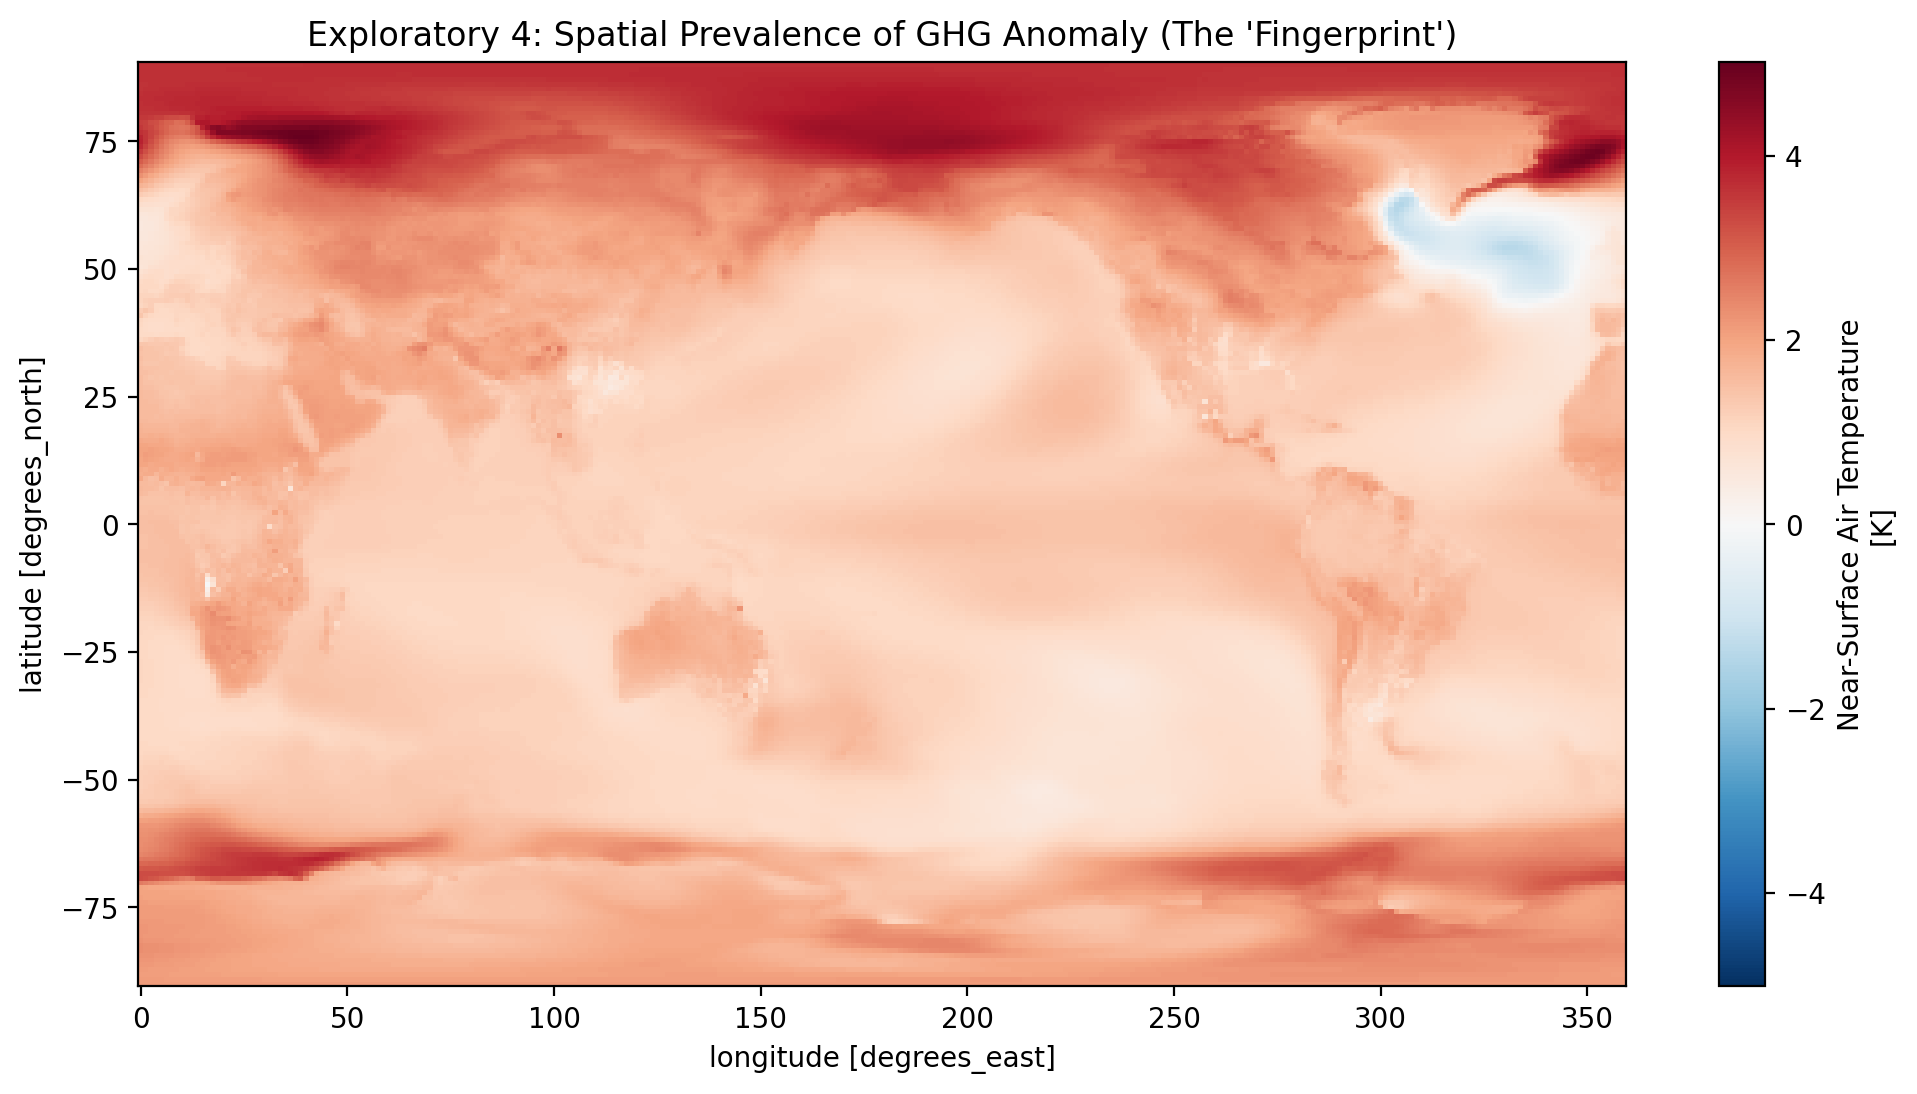

In [16]:
anomaly = modern - baseline
anomaly.plot(cmap='RdBu_r', center=0)
plt.title("Exploratory 4: Spatial Prevalence of GHG Anomaly (The 'Fingerprint')")
plt.show()

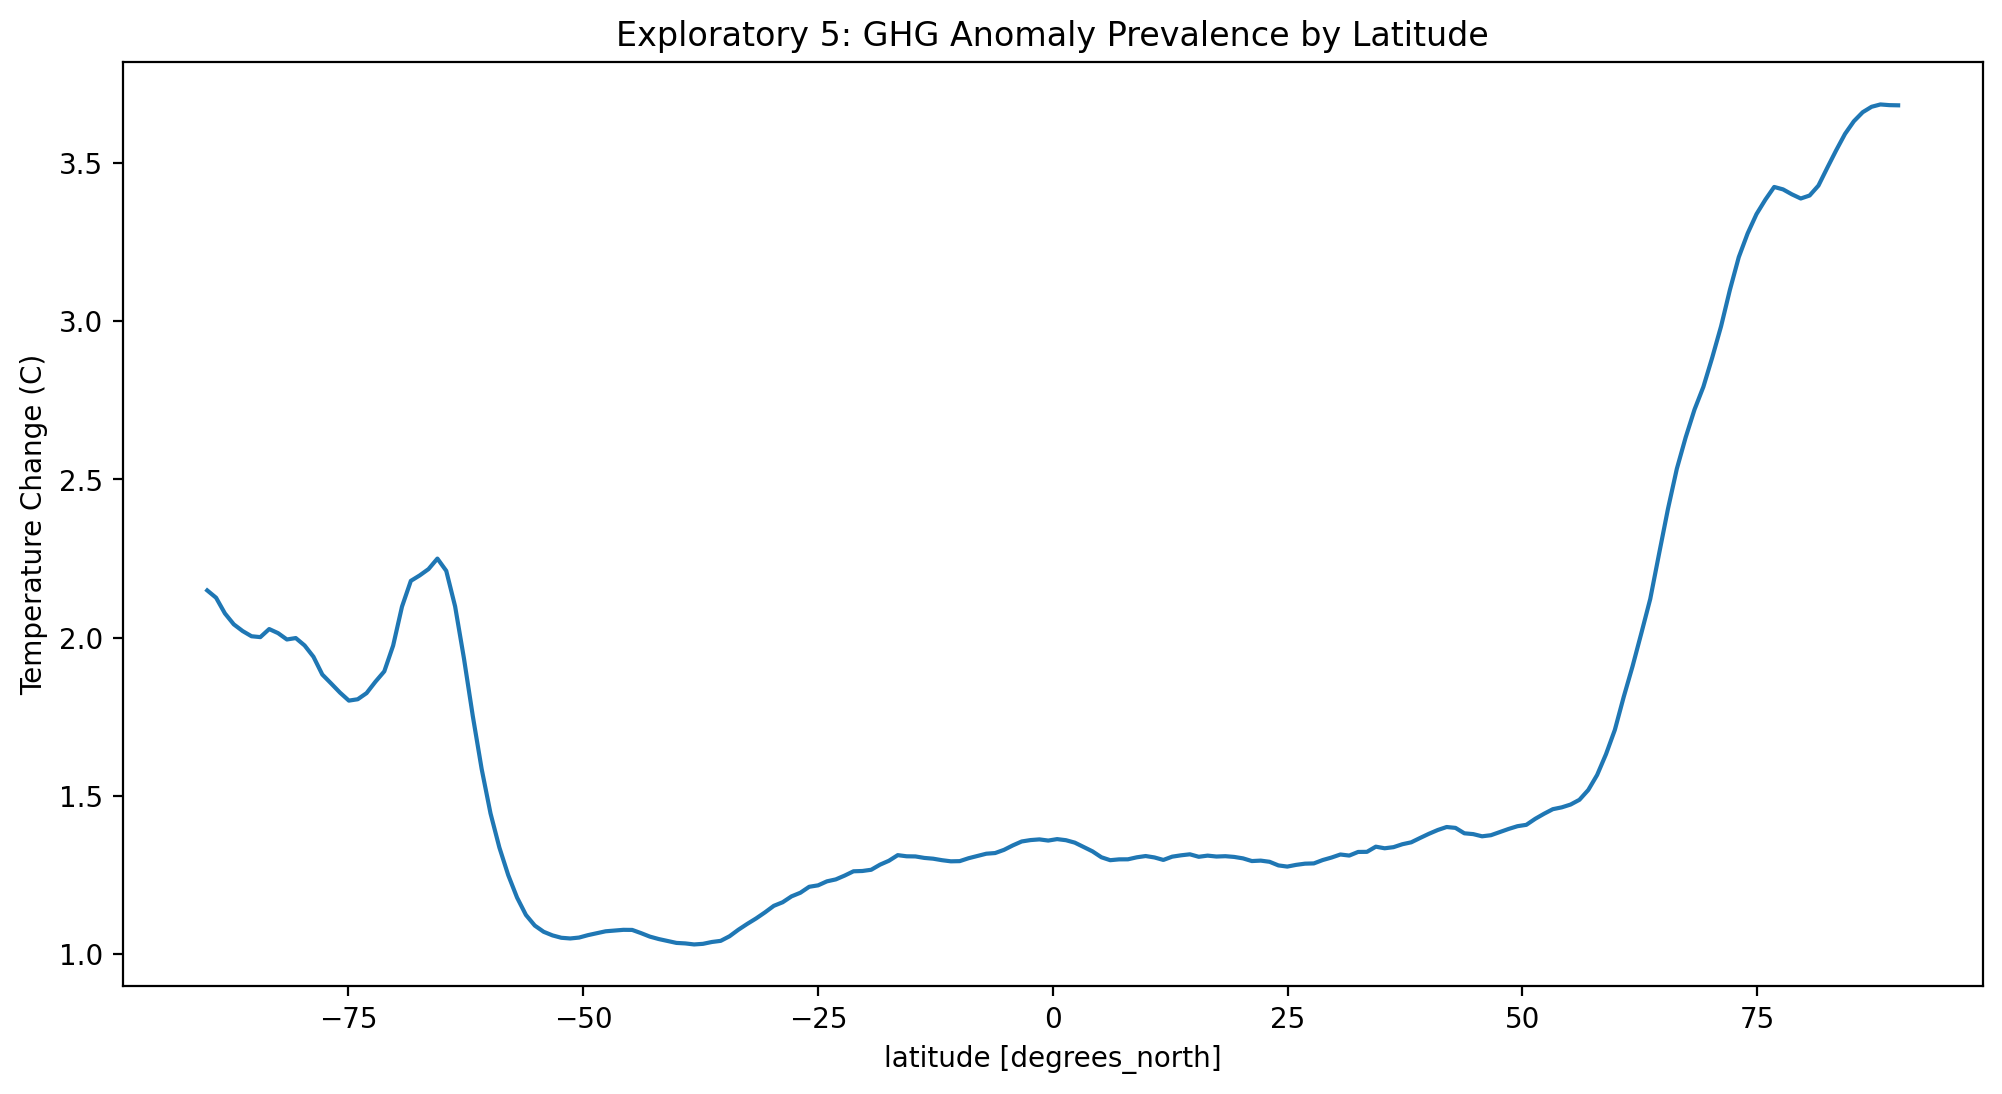

In [17]:
anomaly.mean(dim='lon').plot()
plt.title("Exploratory 5: GHG Anomaly Prevalence by Latitude")
plt.ylabel("Temperature Change (C)")
plt.show()

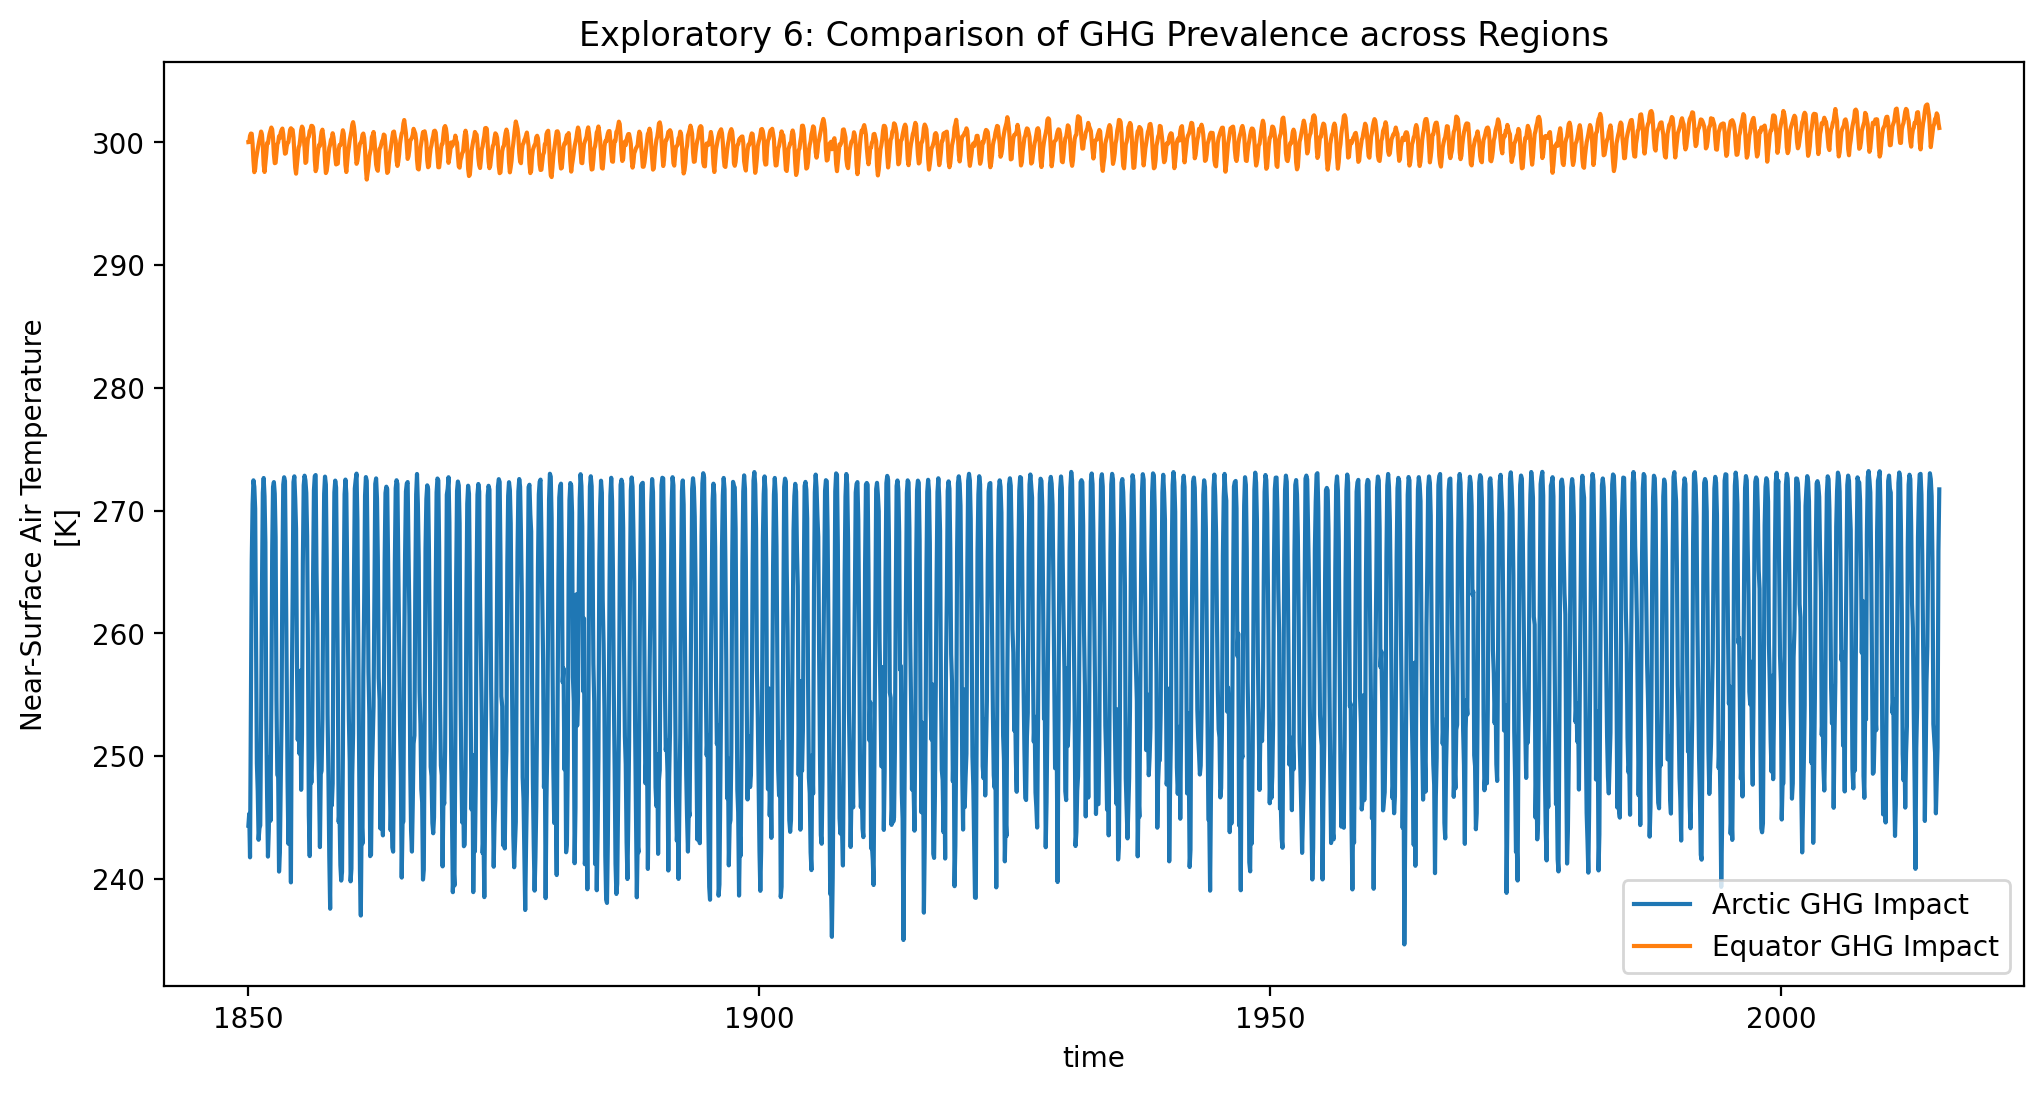

In [18]:
ds.tas.sel(lat=82, lon=0, method='nearest').plot(label='Arctic GHG Impact')
ds.tas.sel(lat=0, lon=0, method='nearest').plot(label='Equator GHG Impact')
plt.legend()
plt.title("Exploratory 6: Comparison of GHG Prevalence across Regions")
plt.show()

In [20]:
small_data = anomaly.coarsen(lat=4, lon=4, boundary="trim").mean()
small_data.to_dataframe(name="anomaly").reset_index().to_csv("ghg_only_anomaly.csv", index=False)
print("GHG-only data exported successfully.")

GHG-only data exported successfully.
